## Part 1: Probability Distributions
Using a relevant dataset sourced online, you will compute the probability density values for each data point using the bivariate normal distribution formula. Implement this from scratch without using any statistical libraries in Python.
Visualize the PDF with Matplotlib using a contour plot and a 3D plot.

In [23]:
# Load Dataset
import math
import pandas as pd

data = pd.read_csv("Advertising.csv")

# Select two continuous variables
x = data["TV"].values
y = data["Sales"].values

n = len(x)
print(n)

200


In [24]:
# finding mean for variables
def compute_mean(values):
    total = 0
    count = 0
    for v in values:
        total += v
        count += 1
    return total / count
mean_x = compute_mean(x)
mean_y = compute_mean(y)
print(x )
print(y)

[230.1  44.5  17.2 151.5 180.8   8.7  57.5 120.2   8.6 199.8  66.1 214.7
  23.8  97.5 204.1 195.4  67.8 281.4  69.2 147.3 218.4 237.4  13.2 228.3
  62.3 262.9 142.9 240.1 248.8  70.6 292.9 112.9  97.2 265.6  95.7 290.7
 266.9  74.7  43.1 228.  202.5 177.  293.6 206.9  25.1 175.1  89.7 239.9
 227.2  66.9 199.8 100.4 216.4 182.6 262.7 198.9   7.3 136.2 210.8 210.7
  53.5 261.3 239.3 102.7 131.1  69.   31.5 139.3 237.4 216.8 199.1 109.8
  26.8 129.4 213.4  16.9  27.5 120.5   5.4 116.   76.4 239.8  75.3  68.4
 213.5 193.2  76.3 110.7  88.3 109.8 134.3  28.6 217.7 250.9 107.4 163.3
 197.6 184.9 289.7 135.2 222.4 296.4 280.2 187.9 238.2 137.9  25.   90.4
  13.1 255.4 225.8 241.7 175.7 209.6  78.2  75.1 139.2  76.4 125.7  19.4
 141.3  18.8 224.  123.1 229.5  87.2   7.8  80.2 220.3  59.6   0.7 265.2
   8.4 219.8  36.9  48.3  25.6 273.7  43.  184.9  73.4 193.7 220.5 104.6
  96.2 140.3 240.1 243.2  38.   44.7 280.7 121.  197.6 171.3 187.8   4.1
  93.9 149.8  11.7 131.7 172.5  85.7 188.4 163.5 11

In [25]:
# standard deviation for each variable
std_x = math.sqrt(sum((xi - mean_x)**2 for xi in x) / n)
std_y = math.sqrt(sum((xi - mean_y)**2 for xi in x) / n)
print(std_x )
print(std_y)

85.63933175679271
158.20371532852823


In [26]:
# correlation  coeffiecent
numerator = sum((x[i] - mean_x)*(y[i] - mean_y) for i in range(n))

denom_x = math.sqrt(sum((xi - mean_x)**2 for xi in x))
denom_y = math.sqrt(sum((yi - mean_y)**2 for yi in y))

cho= numerator / (denom_x * denom_y)
print(numerator)
print(denom_x)
print(denom_y)
print(cho)


69727.64874999998
1211.1230444302516
73.60128225785199
0.7822244248616059


In [27]:
# bivariate normal PDF
def bivariate_pdf(x_val, y_val, mu_x, mu_y, sigma_x, sigma_y, rho):
    coeff = 1 / (2 * math.pi * sigma_x * sigma_y * math.sqrt(1 - rho**2))

    term1 = ((x_val - mu_x) / sigma_x) ** 2
    term2 = ((y_val - mu_y) / sigma_y) ** 2
    term3 = -2 * rho * ((x_val - mu_x) / sigma_x) * ((y_val - mu_y) / sigma_y)

    exponent = -1 / (2 * (1 - cho**2)) * (term1 + term3 + term2)

    return coeff * math.exp(exponent)

In [28]:
# Compute PDF Value for Each Data Point
pdf_values = []

for i in range(n):
    pdf_val = bivariate_pdf(x[i], y[i], mean_x, mean_y, std_x, std_y, cho)
    pdf_values.append(pdf_val)

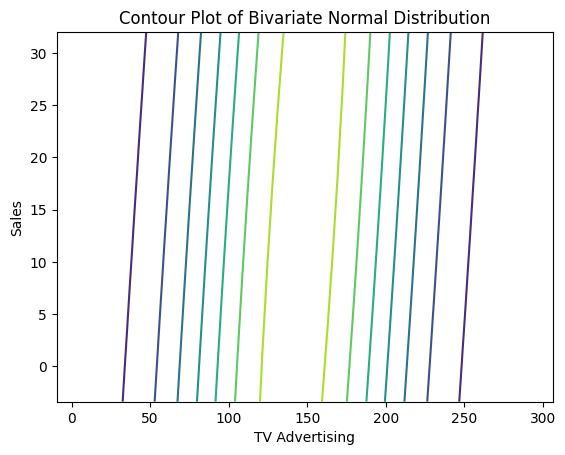

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# Create range slightly beyond data
x_min, x_max = min(x) - 10, max(x) + 10
y_min, y_max = min(y) - 5, max(y) + 5

x_grid = np.linspace(x_min, x_max, 100)
y_grid = np.linspace(y_min, y_max, 100)

X, Y = np.meshgrid(x_grid, y_grid)

Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = bivariate_pdf(
            X[i, j],
            Y[i, j],
            mean_x, mean_y,
            std_x, std_y,
            cho
        )


plt.figure()
plt.contour(X, Y, Z)
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("Contour Plot of Bivariate Normal Distribution")
plt.show()

## Part 2: Bayesian Probability
You will use IMDb Movie Reviews DatasetLinks to an external site. for this part of the assignment. Load the dataset using pandas

In [30]:
import pandas as pd
import re

# 1. Load & Preprocess

df = pd.read_csv("IMDB Dataset.csv")
df.columns = [col.strip().lower() for col in df.columns]
df['sentiment'] = df['sentiment'].str.strip().str.lower()

def clean_review(text):
    """Lowercase and strip all non-alphabetic characters from a review."""
    return re.sub(r'[^a-z\\s]', '', str(text).lower())

df['review_clean'] = df['review'].apply(clean_review)

print(f"Dataset loaded: {len(df):,} reviews")
print(f"Sentiment values: {df['sentiment'].unique()}\\n")

Dataset loaded: 50,000 reviews
Sentiment values: ['positive' 'negative']\n


In [31]:
# 2. Prior Probabilities
# P(Positive) is computed directly from the data rather than assumed.


total_count  = len(df)
pos_reviews  = df[df['sentiment'] == 'positive']
neg_reviews  = df[df['sentiment'] == 'negative']

p_positive = len(pos_reviews) / total_count
p_negative = 1 - p_positive

print(f"P(Positive) = {len(pos_reviews):,} / {total_count:,} = {p_positive:.4f}")
print(f"P(Negative) = {len(neg_reviews):,} / {total_count:,} = {p_negative:.4f}\\n")

P(Positive) = 25,000 / 50,000 = 0.5000
P(Negative) = 25,000 / 50,000 = 0.5000\n


In [32]:
# 3. Keyword Selection & Justification
keywords = ['brilliant', 'amazing', 'terrible', 'horrible']

In [33]:
# 4. Bayes' Theorem Implementation

def count_keyword_in(pattern, review_series):
    """Count how many reviews in a Series contain the keyword pattern."""
    return sum(1 for review in review_series if re.search(pattern, review))

def compute_bayes(keyword, pos_reviews, neg_reviews, p_positive, p_negative):
    """
    Apply Bayes' Theorem to compute posterior P(Positive | keyword).

    Returns a dict with Prior, Likelihood, Marginal, and Posterior.
    """
    pattern = r'\\b' + keyword + r'\\b'

    # Likelihoods
    kw_in_pos      = count_keyword_in(pattern, pos_reviews['review_clean'])
    kw_in_neg      = count_keyword_in(pattern, neg_reviews['review_clean'])
    p_kw_given_pos = kw_in_pos / len(pos_reviews)
    p_kw_given_neg = kw_in_neg / len(neg_reviews)

    # Marginal — Law of Total Probability
    p_kw = (p_kw_given_pos * p_positive) + (p_kw_given_neg * p_negative)

    # Posterior — Bayes' Theorem
    posterior = (p_kw_given_pos * p_positive) / p_kw if p_kw > 0 else 0.0

    return {
        'Keyword'    : keyword,
        'Prior'      : round(p_positive,     4),
        'Likelihood' : round(p_kw_given_pos, 4),
        'Marginal'   : round(p_kw,           4),
        'Posterior'  : round(posterior,      4)
    }

results = [compute_bayes(kw, pos_reviews, neg_reviews, p_positive, p_negative)
           for kw in keywords]

In [34]:
# 5. Results Table

results_df = pd.DataFrame(results).set_index('Keyword')
print(results_df.to_markdown())

| Keyword   |   Prior |   Likelihood |   Marginal |   Posterior |
|:----------|--------:|-------------:|-----------:|------------:|
| brilliant |     0.5 |            0 |          0 |           0 |
| amazing   |     0.5 |            0 |          0 |           0 |
| terrible  |     0.5 |            0 |          0 |           0 |
| horrible  |     0.5 |            0 |          0 |           0 |


In [35]:
# 6. Interpretation

for r in results:
    shift = round(r['Posterior'] - r['Prior'], 4)
    direction = "↑ positive signal" if shift > 0 else "↓ negative signal"
    print(f"  {r['Keyword']:<12}  Prior={r['Prior']}  →  Posterior={r['Posterior']}  "
          f"(shift {shift:+.4f}  {direction})")

  brilliant     Prior=0.5  →  Posterior=0.0  (shift -0.5000  ↓ negative signal)
  amazing       Prior=0.5  →  Posterior=0.0  (shift -0.5000  ↓ negative signal)
  terrible      Prior=0.5  →  Posterior=0.0  (shift -0.5000  ↓ negative signal)
  horrible      Prior=0.5  →  Posterior=0.0  (shift -0.5000  ↓ negative signal)


## Part 3: Gradient Descent Manual Calculation
Objective:
You will manually compute three updates of the gradient descent algorithm for the parameters
  M and B
 in a simple linear regression model.

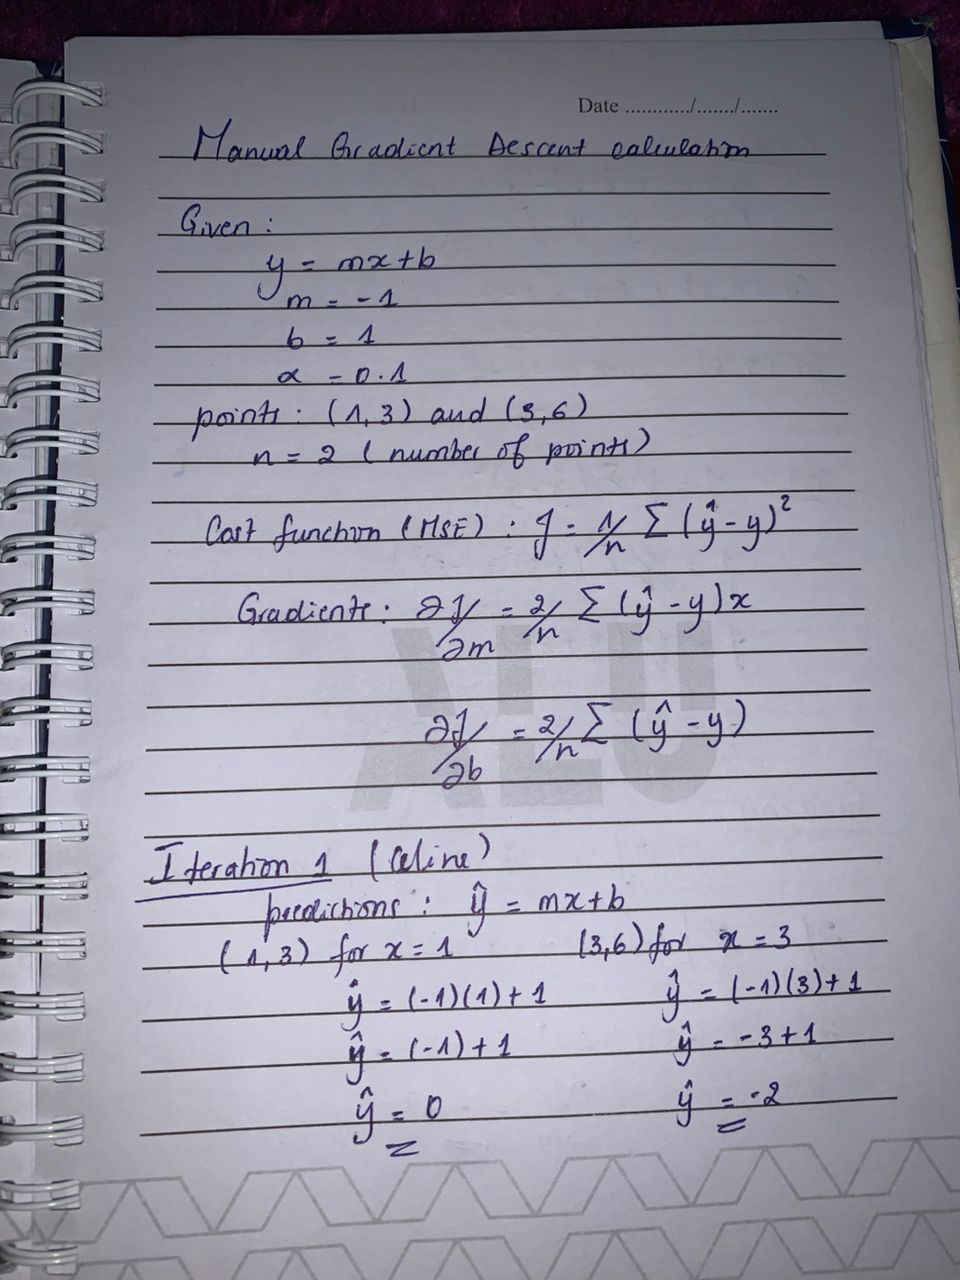

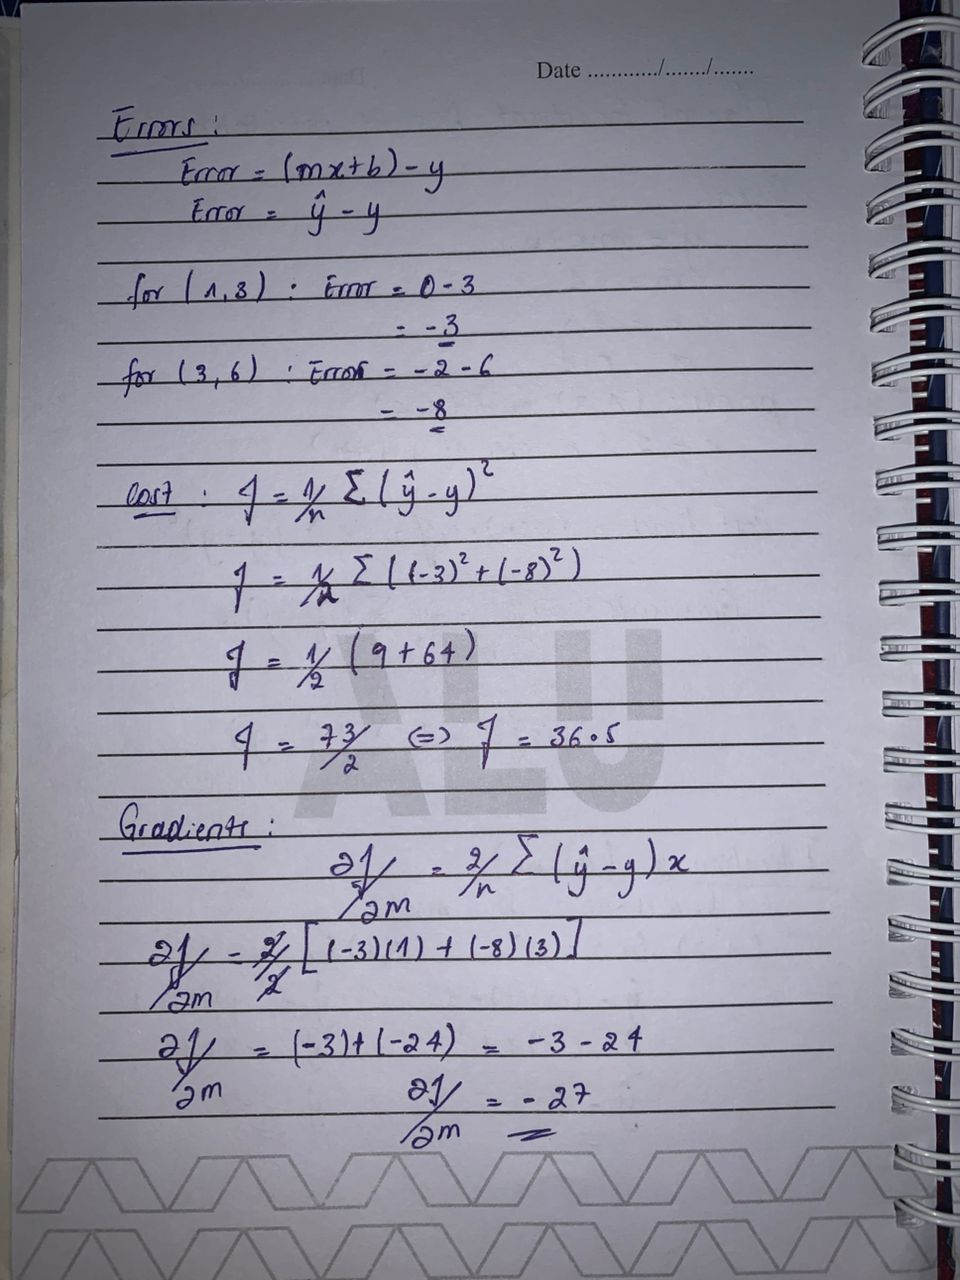

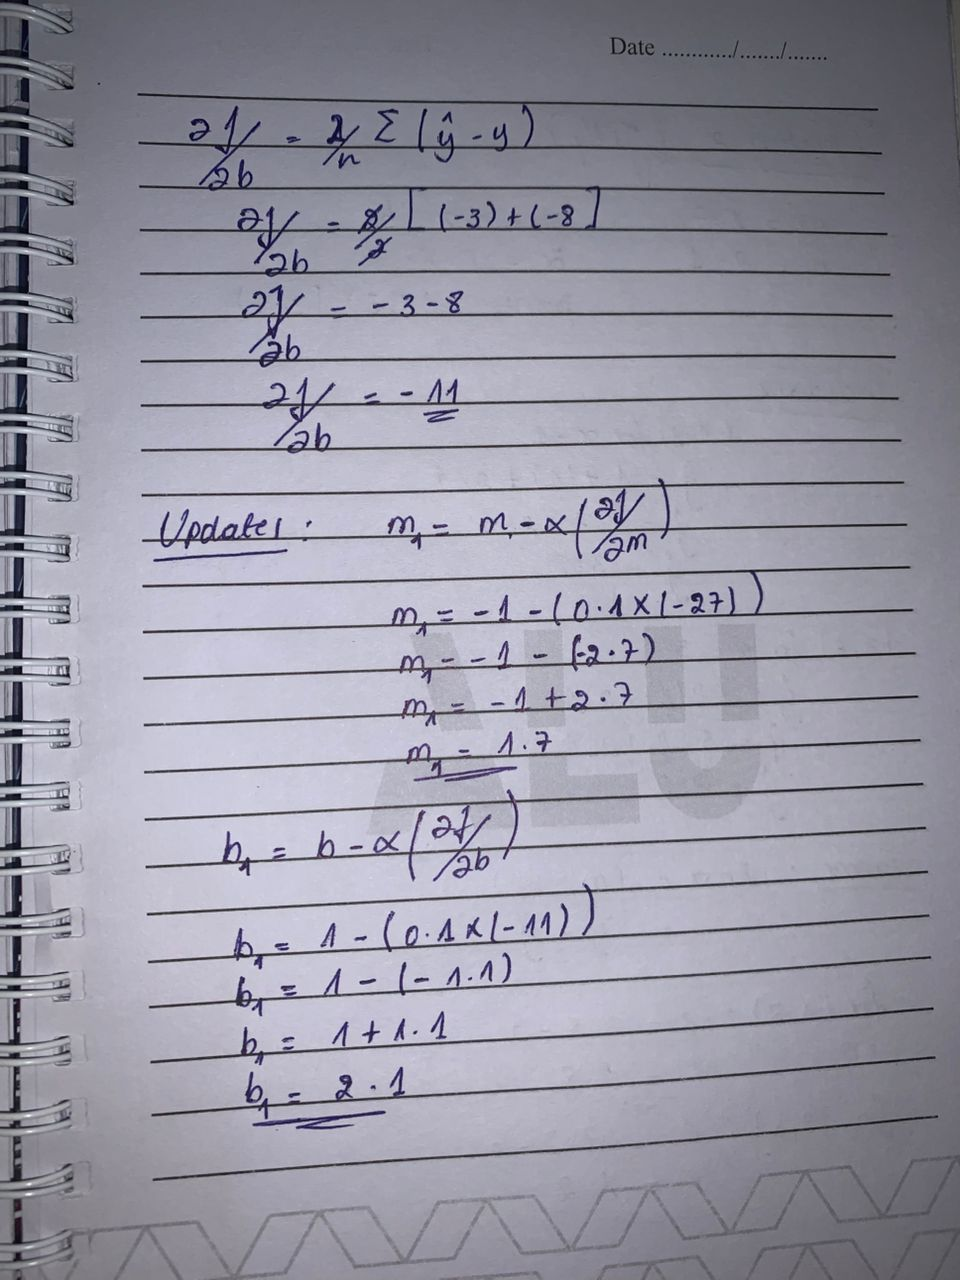

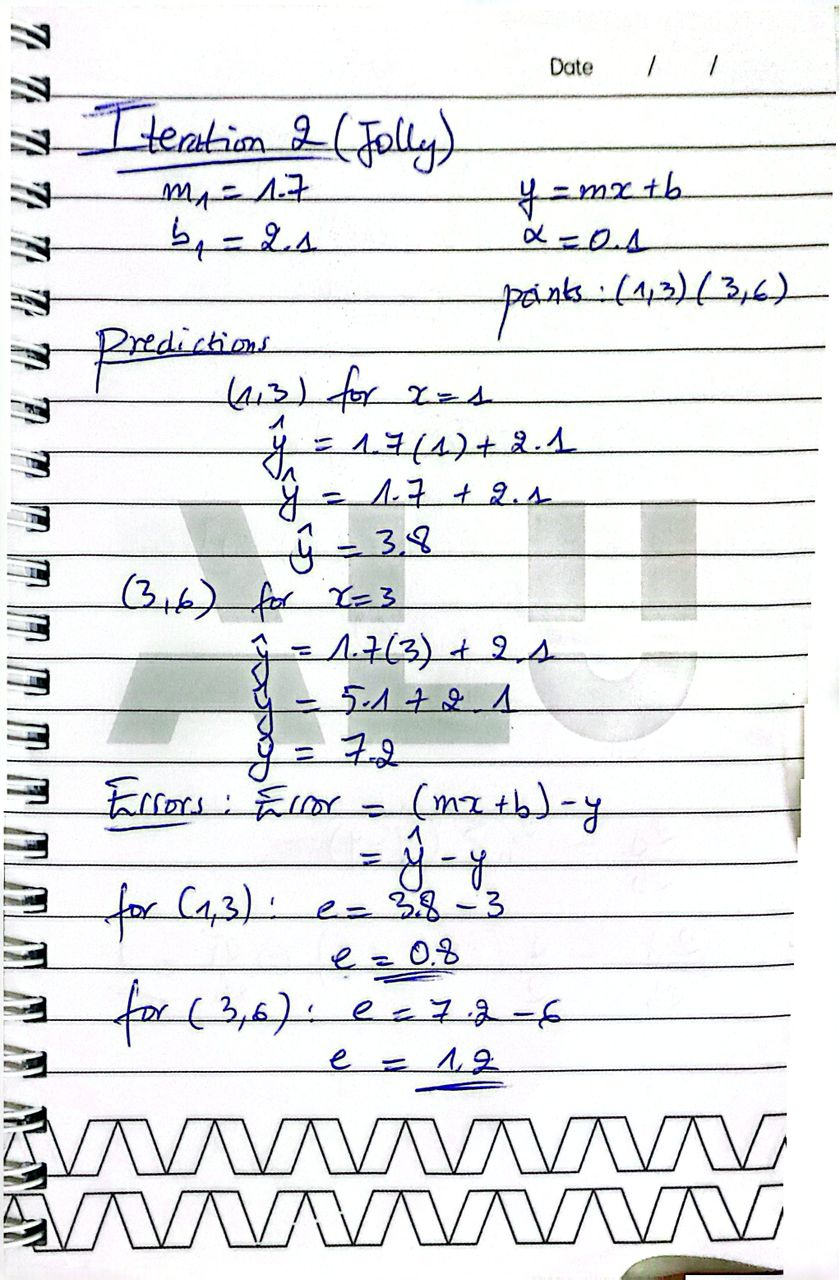

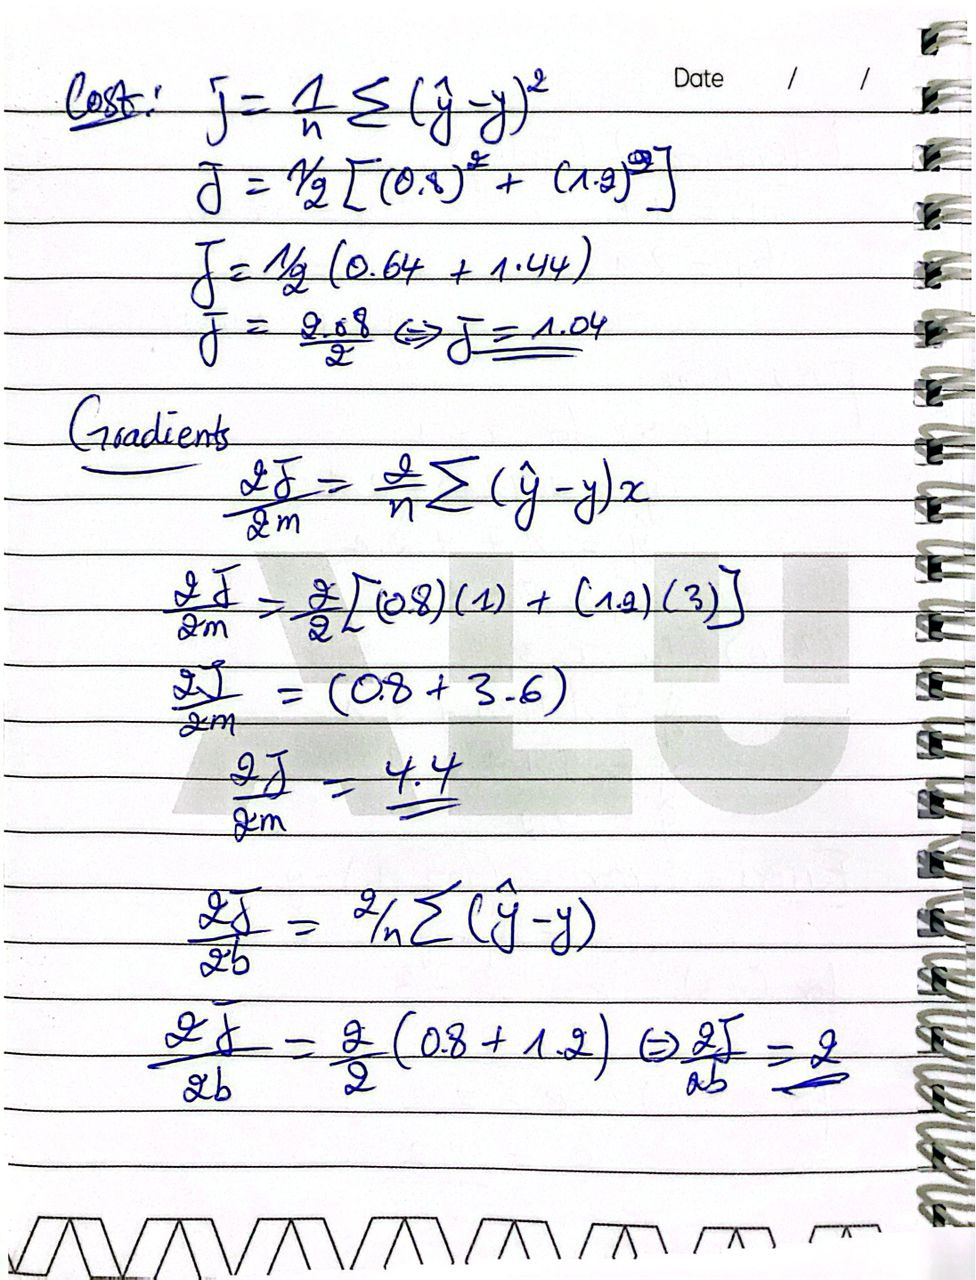

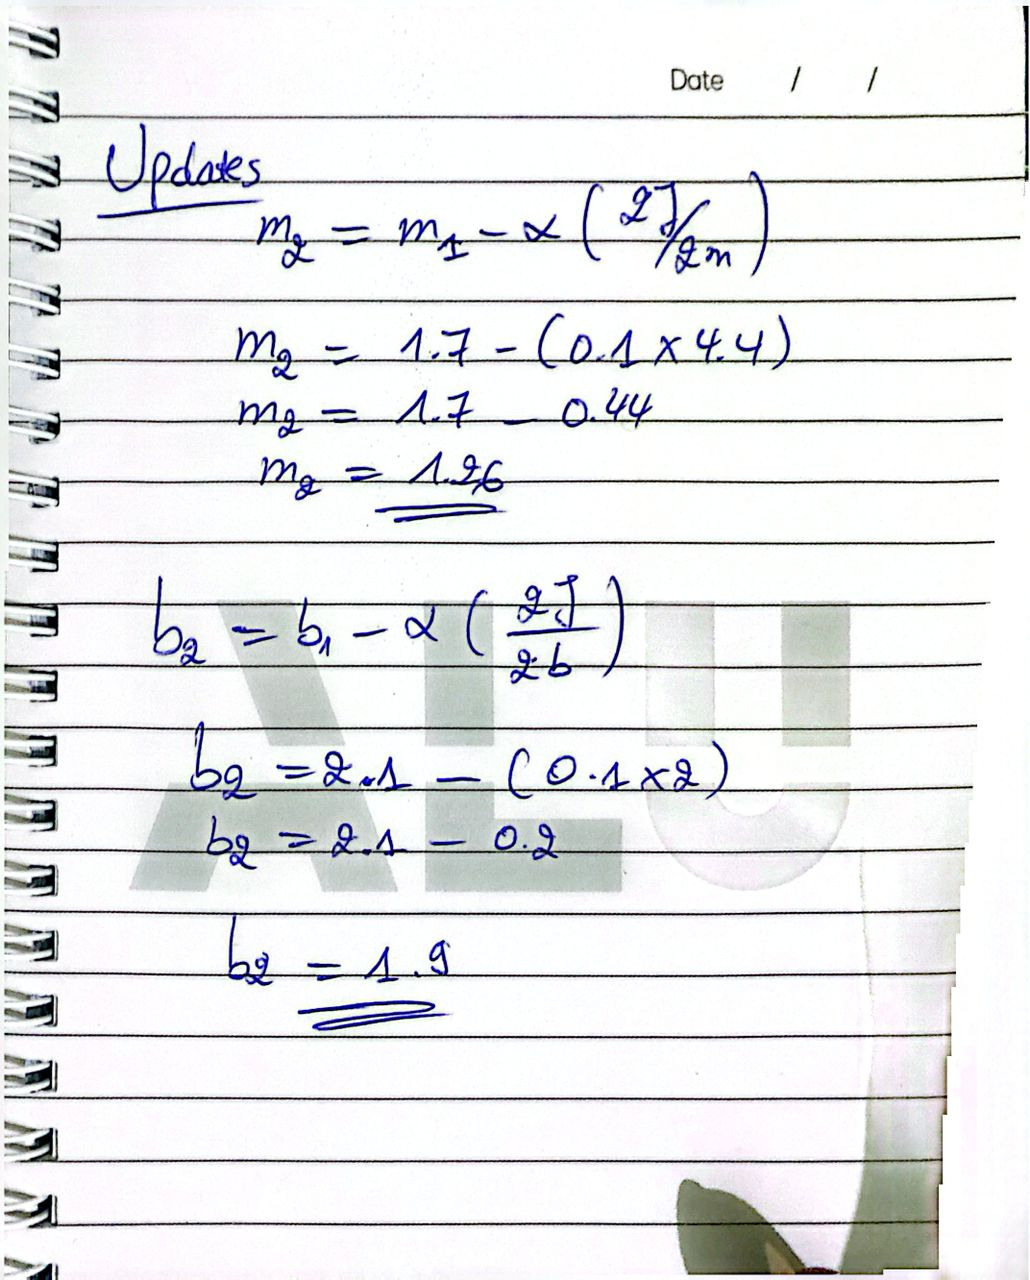

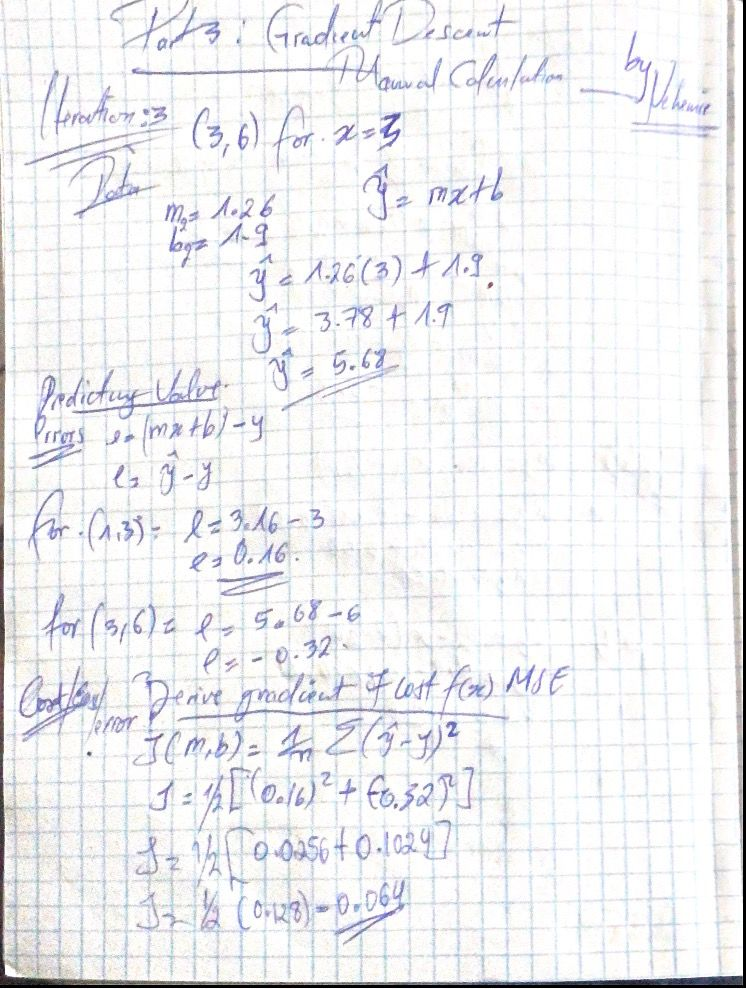

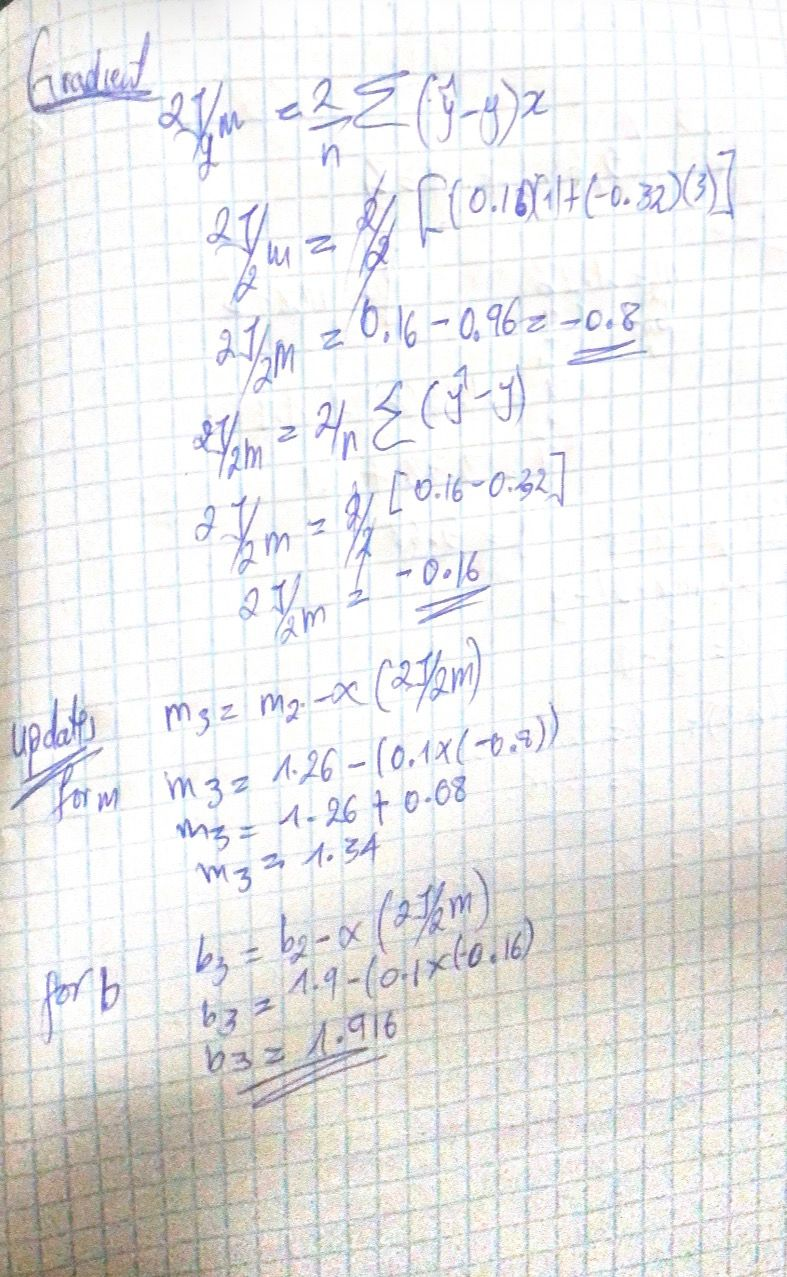

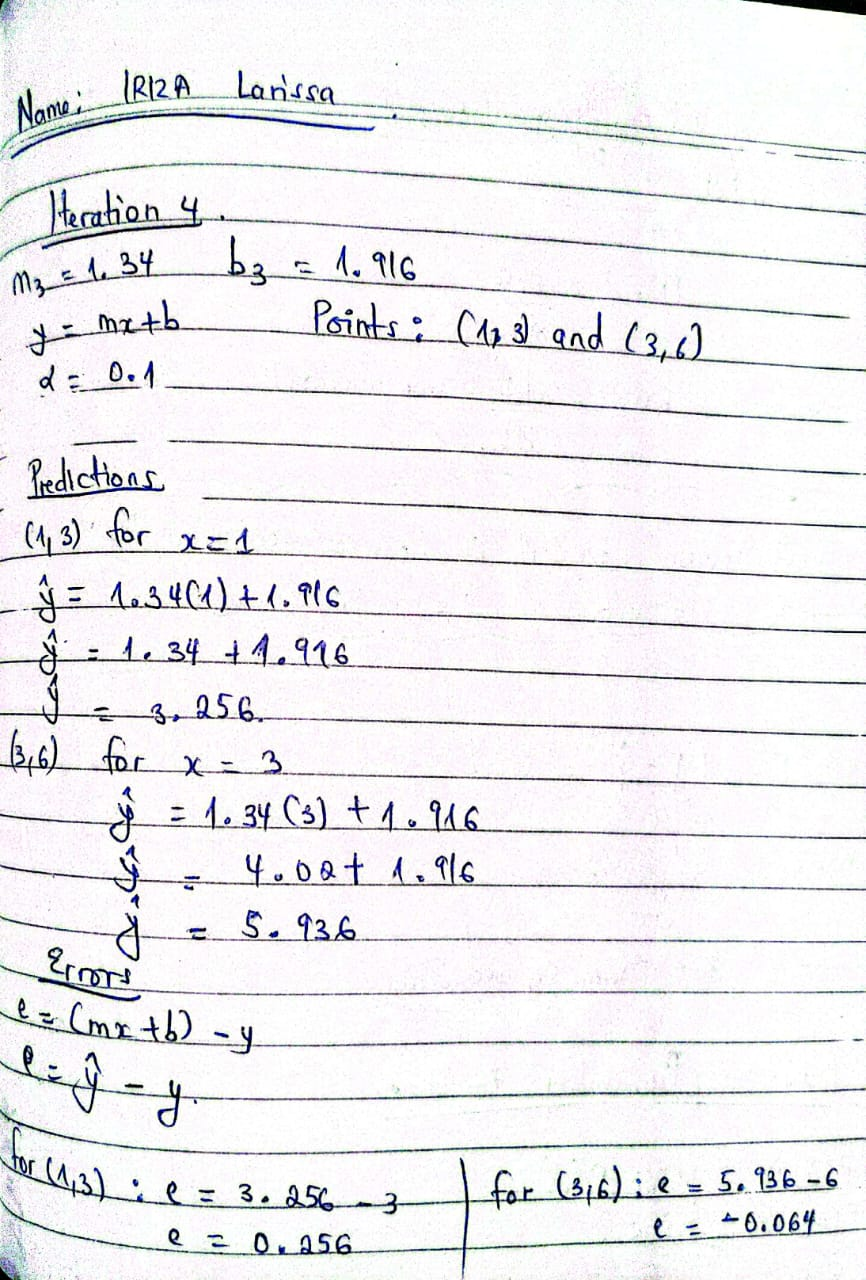

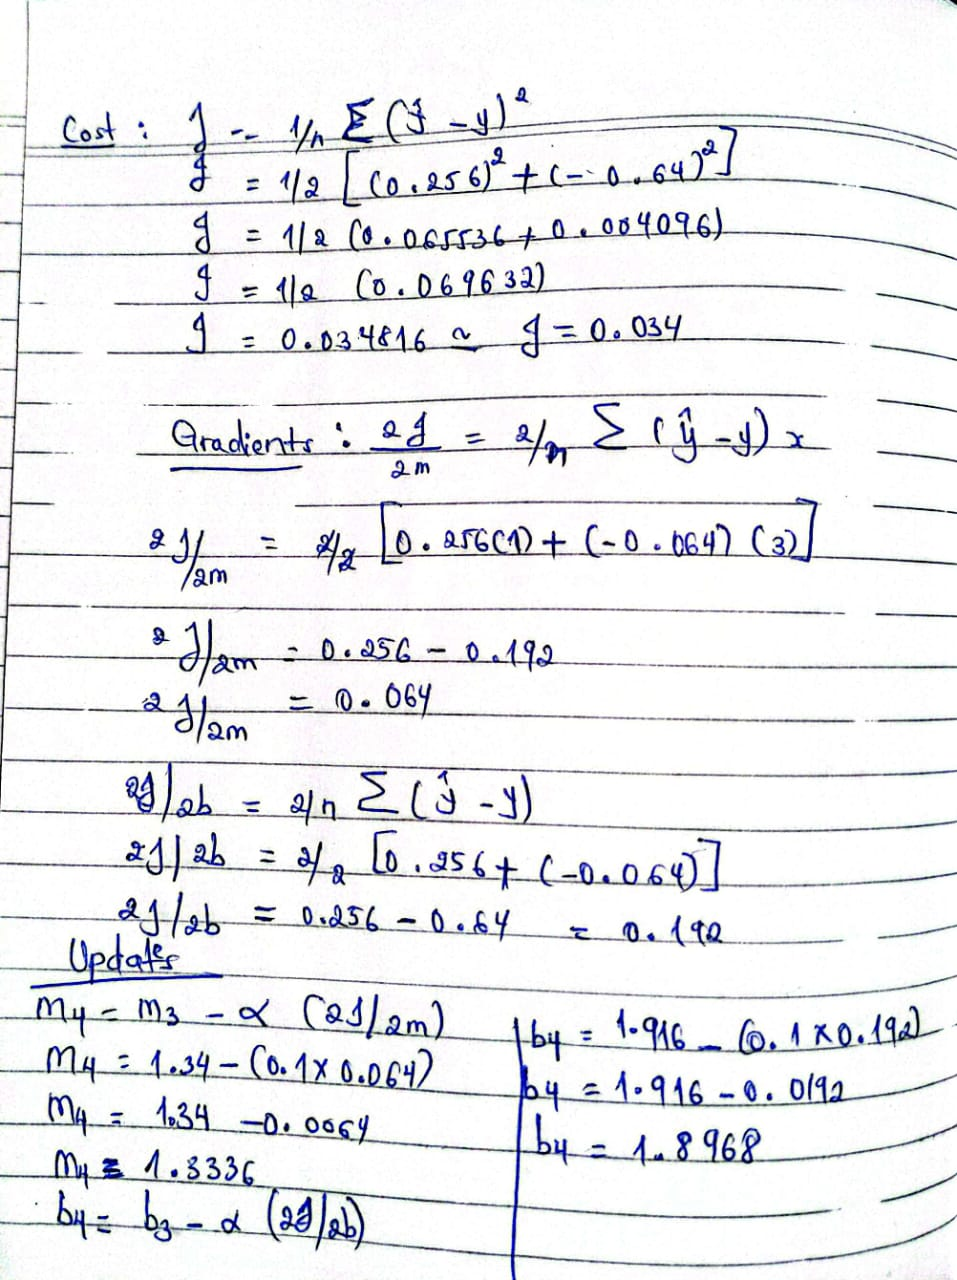

## Part 4: Gradient Descent in Code

In [36]:
# Step 1 : Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import approx_fprime

# Given from Part 3 Manual Calculation
X     = np.array([1, 3], dtype=float)
Y     = np.array([2, 4], dtype=float)
alpha = 0.01
n     = len(X)
m, b  = 0.0, 0.0

print(f"Data Points : {list(zip(X, Y))}")
print(f"Initial m={m}, b={b}, α={alpha}")


Data Points : [(np.float64(1.0), np.float64(2.0)), (np.float64(3.0), np.float64(4.0))]
Initial m=0.0, b=0.0, α=0.01


In [37]:
#step2  Compute predicted values
def predict(m, b, X):
    """Compute predicted values: ŷ = mX + b"""
    return m * X + b

def compute_cost(m, b, X, Y):
    """MSE Cost Function: J = (1/n) * Σ(y - ŷ)²"""
    errors = Y - predict(m, b, X)
    return (1 / n) * np.sum(errors ** 2)

def compute_gradients(m, b, X, Y):
    """
    Chain Rule Partial Derivatives:
      ∂J/∂m = (-2/n) * Σ xᵢ(yᵢ - ŷᵢ)
      ∂J/∂b = (-2/n) * Σ    (yᵢ - ŷᵢ)
    SciPy approx_fprime verifies our analytical gradients numerically.
    """
    errors    = Y - predict(m, b, X)
    dJ_dm     = (-2 / n) * np.sum(X * errors)
    dJ_db     = (-2 / n) * np.sum(errors)
    cost_fn   = lambda params: compute_cost(params[0], params[1], X, Y)
    numerical = approx_fprime([m, b], cost_fn, epsilon=1e-6)
    return dJ_dm, dJ_db, numerical

def update_parameters(m, b, dJ_dm, dJ_db, alpha):
    """
    Gradient Descent Update Rule:
      m_new = m - α * ∂J/∂m
      b_new = b - α * ∂J/∂b
    """
    m_new = m - alpha * dJ_dm
    b_new = b - alpha * dJ_db
    return m_new, b_new

print("Functions defined: predict | compute_cost | compute_gradients | update_parameters")


Functions defined: predict | compute_cost | compute_gradients | update_parameters


In [38]:
#Step 3 — Gradient Descent Loop
# Reset to initial values
m, b    = 0.0, 0.0
members = ['Celine', 'Nehemie', 'Jolly', 'Larissa']

# Storage for plots
history = {'iteration': [0], 'm': [m], 'b': [b],
           'cost': [compute_cost(m, b, X, Y)]}

print("=" * 68)
print(f"{'GRADIENT DESCENT — 4 ITERATIONS':^68}")
print("=" * 68)

for i in range(1, 5):
    member          = members[i - 1]
    y_hat           = predict(m, b, X)
    errors          = Y - y_hat
    dJ_dm, dJ_db, numerical = compute_gradients(m, b, X, Y)
    m_new, b_new    = update_parameters(m, b, dJ_dm, dJ_db, alpha)
    cost_new        = compute_cost(m_new, b_new, X, Y)

    print(f"\n{'─'*68}")
    print(f"  Iteration {i}  |  Member: {member}")
    print(f"{'─'*68}")
    print(f"  Current       →  m = {m:.4f},  b = {b:.4f}")
    print(f"  Predictions   →  ŷ₁ = {y_hat[0]:.4f},  ŷ₂ = {y_hat[1]:.4f}")
    print(f"  Errors        →  e₁ = {errors[0]:.4f},  e₂ = {errors[1]:.4f}")
    print(f"  ∂J/∂m         →  Analytical = {dJ_dm:.4f}  |  SciPy = {numerical[0]:.4f}")
    print(f"  ∂J/∂b         →  Analytical = {dJ_db:.4f}  |  SciPy = {numerical[1]:.4f}")
    print(f"  Update m      →  {m:.4f} - ({alpha}) × ({dJ_dm:.4f}) = {m_new:.4f}")
    print(f"  Update b      →  {b:.4f} - ({alpha}) × ({dJ_db:.4f}) = {b_new:.4f}")
    print(f"  New Cost J    →  {cost_new:.6f}")

    history['iteration'].append(i)
    history['m'].append(m_new)
    history['b'].append(b_new)
    history['cost'].append(cost_new)

    m, b = m_new, b_new

print(f"\n{'='*68}")
print(f"  Final  →  m = {m:.4f},  b = {b:.4f},  J = {compute_cost(m, b, X, Y):.6f}")
print(f"{'='*68}")

y_final = predict(m, b, X)

print("Final Predictions using learned m and b:")
print(f"  m = {m:.4f},  b = {b:.4f}\n")
for xi, yi, yhat in zip(X, Y, y_final):
    print(f"  x = {xi:.0f}  →  Actual y = {yi:.1f},  Predicted ŷ = {yhat:.4f},  "
          f"Residual = {yi - yhat:.4f}")


                  GRADIENT DESCENT — 4 ITERATIONS                   

────────────────────────────────────────────────────────────────────
  Iteration 1  |  Member: Celine
────────────────────────────────────────────────────────────────────
  Current       →  m = 0.0000,  b = 0.0000
  Predictions   →  ŷ₁ = 0.0000,  ŷ₂ = 0.0000
  Errors        →  e₁ = 2.0000,  e₂ = 4.0000
  ∂J/∂m         →  Analytical = -14.0000  |  SciPy = -14.0000
  ∂J/∂b         →  Analytical = -6.0000  |  SciPy = -6.0000
  Update m      →  0.0000 - (0.01) × (-14.0000) = 0.1400
  Update b      →  0.0000 - (0.01) × (-6.0000) = 0.0600
  New Cost J    →  7.815200

────────────────────────────────────────────────────────────────────
  Iteration 2  |  Member: Nehemie
────────────────────────────────────────────────────────────────────
  Current       →  m = 0.1400,  b = 0.0600
  Predictions   →  ŷ₁ = 0.2000,  ŷ₂ = 0.4800
  Errors        →  e₁ = 1.8000,  e₂ = 3.5200
  ∂J/∂m         →  Analytical = -12.3600  |  SciPy = -12.

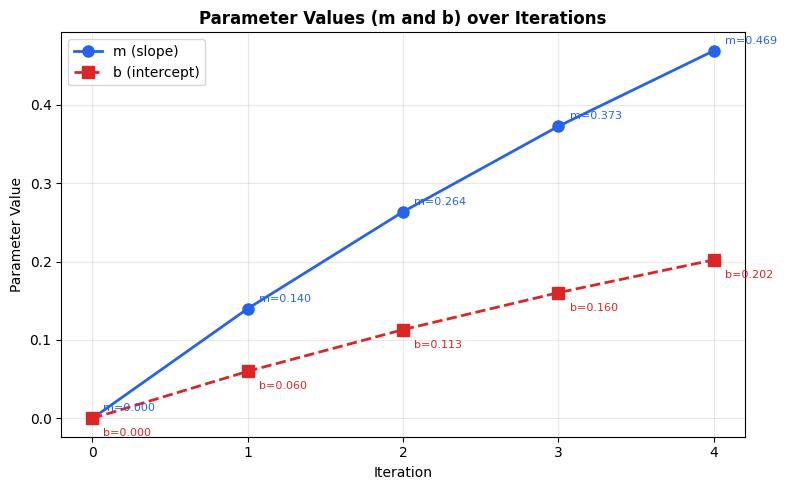

In [39]:
#step 4 — Plot 1: m and b over Iterations
iters = history['iteration']

plt.figure(figsize=(8, 5))
plt.plot(iters, history['m'], 'o-', color='#2563EB',
         linewidth=2, markersize=8, label='m (slope)')
plt.plot(iters, history['b'], 's--', color='#DC2626',
         linewidth=2, markersize=8, label='b (intercept)')

for i, (mv, bv) in enumerate(zip(history['m'], history['b'])):
    plt.annotate(f"m={mv:.3f}", (iters[i], mv),
                 textcoords="offset points", xytext=(8, 5), fontsize=8, color='#2563EB')
    plt.annotate(f"b={bv:.3f}", (iters[i], bv),
                 textcoords="offset points", xytext=(8, -13), fontsize=8, color='#DC2626')

plt.title('Parameter Values (m and b) over Iterations', fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Parameter Value')
plt.xticks(iters)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot1_parameters.png', dpi=150, bbox_inches='tight')
plt.show()


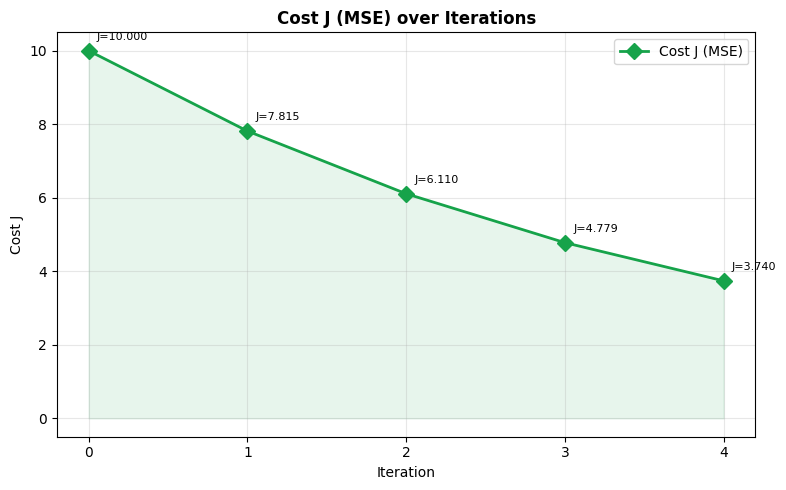

In [40]:
# step 5 — Plot 2: Cost J over Iterations
plt.figure(figsize=(8, 5))
plt.plot(iters, history['cost'], 'D-', color='#16A34A',
         linewidth=2, markersize=8, label='Cost J (MSE)')
plt.fill_between(iters, history['cost'], alpha=0.1, color='#16A34A')

for i, cost in enumerate(history['cost']):
    plt.annotate(f"J={cost:.3f}", (iters[i], cost),
                 textcoords="offset points", xytext=(6, 8), fontsize=8)

plt.title('Cost J (MSE) over Iterations', fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Cost J')
plt.xticks(iters)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_cost.png', dpi=150, bbox_inches='tight')
plt.show()



In [41]:
summary = pd.DataFrame({
    'Iteration' : iters,
    'Member'    : ['— (Initial)', 'Celine', 'Nehemie', 'Jolly', 'Larissa'],
    'm'         : [round(v, 4) for v in history['m']],
    'b'         : [round(v, 4) for v in history['b']],
    'Cost J'    : [round(v, 6) for v in history['cost']]
})

print(summary.to_markdown(index=False))


|   Iteration | Member      |      m |      b |   Cost J |
|------------:|:------------|-------:|-------:|---------:|
|           0 | — (Initial) | 0      | 0      | 10       |
|           1 | Celine      | 0.14   | 0.06   |  7.8152  |
|           2 | Nehemie     | 0.2636 | 0.1132 |  6.11    |
|           3 | Jolly       | 0.3727 | 0.1604 |  4.7791  |
|           4 | Larissa     | 0.469  | 0.2023 |  3.74032 |
